<a href="https://colab.research.google.com/github/ji0-k/AI_26/blob/main/07_03_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D%EA%B8%B0%ED%83%80%EB%8F%84%EA%B5%AC(%EB%93%9C%EB%A1%AD%EC%95%84%EC%9B%83%2C%EC%BD%9C%EB%B0%B1%2C%EC%A1%B0%EA%B8%B0%EC%A2%85%EB%A3%8C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 인공신경망을 구성하는 절차
# 1. 더미데이터 준비 및 전처리(딥러닝은 데이터의 수치 범위에 민감)
# 2. 훈련용, 검증용, 테스트용으로 나눔
# 3. 심층을 만듬(dense)
# 4. model에 적용(Sequential)
# 5. 컴파일 진행(최적화기법을 적용 : adam)
# 6. fit(훈련)
# 7. evaluate(검증)
# 8. predict(예측)

In [2]:
# 인공신경망(ANN) 구성 5단계 절차 (gem)

# 1. 데이터 준비 및 전처리(Data Preparation)
#    : 특성스케일링(데이터범위0~1사이) / 데이터분할 (train,validation,test)

# 2. 모델 구조 정의 (Model Definition)
#    : 입력층(Input Layer): 데이터의 형태(Shape)를 결정
#      은닉층(Hidden Layers): 뉴런 개수와 층의 깊이를 설정, 활성화 함수(ReLU 등)를 적용
#      출력층(Output Layer): 해결하려는 문제(분류/회귀)에 따라 뉴런 수와 활성화 함수(Sigmoid/Softmax)를 정한다

# 3. 컴파일(Compile)
#    : 손실함수(Loss fn.) 정답과 예측값의 차이
#      옵티마이저(Optimizer) 최적화, 가중치 어떻게할지 결정하는 알고리즘(Adam, SGD 등)
#      지표 (Metrics) 모델 성능 평가 기준 (Accuracy)

# 4. 모델 학습 (train / fit)
#    : 에포크(Epochs), 배치사이즈(BatchSize)- 몇개데이터묶어서학습할지,
#      검증(Validation) - 중간중간학습안된데이터로 성능체크 , 이때 콜백,조기종료 사용

# 5. 평가 및 예측 (Evaluation & Prediction)

In [3]:
# 학습 기록(History)과 손실 곡선 확인하기
# fit() 메서드의 반환값: 모델 학습 시 history = model.fit(...)과 같이 변수에 할당하면,
#                        학습 과정 중 발생한 손실(loss)과 평가지표(accuracy) 값이 History 객체에 저장됨.
# 주요 데이터 활용: history.history 딕셔너리를 확인하면 에포크별 상세 수치를 얻을 수 있으며,
#                   matplotlib 라이브러리로 시각화하여 손실 곡선을 그릴 수 있음.
# 학습 상태 진단
#    손실(Loss): 반복될수록 값이 떨어져야 학습이 잘 되는 것임.
#    정확도(Accuracy): 반복될수록 값이 올라가야 함.

#Tip: 코랩에서는 별도의 출력 명령문 없이도 마지막 라인의 객체 정보를 자동으로 표시해주어 편리함

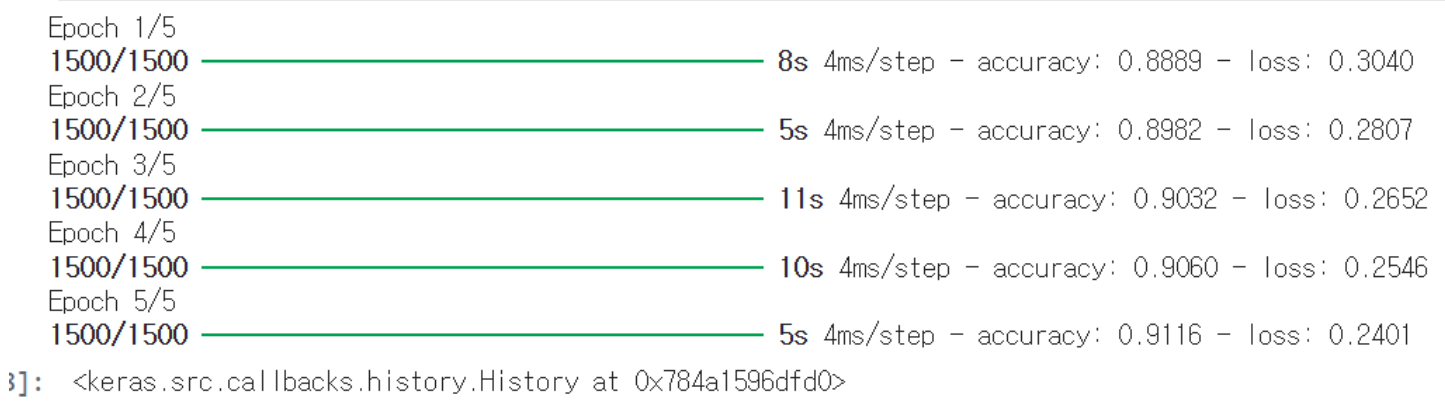

In [4]:
# 데이터 전처리 (data preprocessing)
import tensorflow as tf

# 1. 재현성을 위한 랜덤 시드 고정
tf.keras.utils.set_random_seed(42)
# 2. 연산 결정론 설정
# 내부 연산 순서를 고정하여 하드웨어 차이로 인한 오차까지 잡아줌
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

# 3. 데이터 불러오기
(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()

# 4. 데이터 정규화
# 이미지 0~255사이, 255로나누어 0~1값, 가중치 계산 빠르고 안정적(딥러닝 숫자 작을수록 학습잘)
train_scaled = train_input/255.0

# 5. 검증데이터 세트분리 (Validation Set)
#train_scaled(훈련용)에서 일부(20%)떼서 val_scaled(검증용) 만들기
# 학습하지않은데이터 잘 맞추는지 중간점검 위함
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
# 데이터 무결성 확인(Data Integrity Check)단계
print("훈련데이터 :")
print(train_scaled.shape, train_target.shape)
print("테스트데이터 :")
print(test_input.shape, test_target.shape)
print("검증데이터 :")
print(val_scaled.shape, val_target.shape)

훈련데이터 :
(48000, 28, 28) (48000,)
테스트데이터 :
(10000, 28, 28) (10000,)
검증데이터 :
(12000, 28, 28) (12000,)


In [6]:
# 설계도 바탕으로 모델 찍어내는 함수 만드는 단계
# 다양한 설정 (드롭아웃 유무, 층의 깊이 등)을 실험할 때(유연성)
# 매번 모델을 새로 치는게 아니라 함수 만들어 호출
# 반복방지(오타실수방지)
# 코드 가독성

def model_fn(a_layer=None): # 모델객체생성 반환 , a_layer에 다른층이 있다면 그걸 인자로받음
  model = keras.Sequential() # 층을 쌓는 컨테이너 생성

  # 1.Flatten층 28*28 2차원배열을 784개1차원배열로 펼쳐주는 역할
  # 딥러닝의 Dense밀집층은 1차원 데이터만 받을 수 있기 때문에
  model.add(keras.layers.Flatten(input_shape=(28,28))) # -> (28, 28) → (784,)

  # 2. Dense층 (hidden)  은닉층, 100개의 뉴런 사용하여 특징학습
  # 활성화 함수 relu사용 학습 효율높임,
  model.add(keras.layers.Dense(100,activation='relu'))

  # 3. 매개변수로 받은 층이 있다면 삽입, 없으면 넘어감
  # 여기서 나중에 유연하게 다른 층 넣을 수 있음 (드롭아웃 등)
  if a_layer:
    model.add(a_layer)

  # 4. 출력층 추가 (데이터 10가지종류, 뉴런10개, 다중분)
  model.add(keras.layers.Dense(10, activation='softmax'))

  return model # 완성모델 반환

In [7]:
# 1. 모델생성
# 매개변수(a_layer)없이 호출
# Flatten -> Dense(100) -> Dense(10) 구조의 기본 인공신경망 모델 인스턴스 생성
# 변수 model에 담음
model = model_fn() # 매개값이 없으면 그냥 생성, 매개값이 있으면 모델추가

# 2. 모델 구조 확인
# 생성된 모델의 층 구성, 출력 형태(Output Shape), 학습 가능한 파라미터(가중치) 개수를
# 표 형태로 깔끔하게 요약하여 출력합니다.
model.summary()

# Layer(type) : 사용된 층의 종류
# output shape : 각 층을 통과한 데이터의 형태 , None은 배치 사이즈를의미
# param # : 해당 층에서 모델이 학습해야할 가중치와 절편의 총 개

# 아래 표에서 확인할것
# 데이터의 흐름: Flatten 층 이후에 데이터가 (None, 784)로 잘 펼쳐졌는지 확인하세요.
#               28 * 28 = 784가 되어야 다음 Dense 층과 연결됩니다.
# 파라미터 폭발 주의: 은닉층의 뉴런 수를 너무 늘리면 Total params 숫자가 급격히 증가
#                     파라미터가 너무 많으면 학습 속도가 느려지고 과적합(Overfitting)이 발생

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ReLU(Rectified Linear Unit)는 현대 딥러닝에서 가장 많이 사용되는 활성화 함수(Activation Function)
# 0보다 작으면 0을 내보내고, 0보다 크면 그 값을 그대로 내보낸다

# 경사 소실 문제(Vanishing Gradient) 해결: Sigmoid는 입력값이 커질수록 기울기가 0에 가까워져 학습이 멈추는 문제가 있지만,
# ReLU는 양수 영역에서 기울기가 항상 1이므로 깊은 신경망에서도 학습이 잘 전달됩니다.
# 연산 속도가 매우 빠름: 지수 함수를 계산할 필요 없이 if문 하나로 구현 가능하므로 컴퓨터의 연산 부담이 적다
# 희소성(Sparsity) 생성: 일부 뉴런을 0으로 만들어 모델을 가볍게 하고 중요한 특징에 집중하게 만듭니다.

In [9]:
# 모델 빌드(Build)' 또는 '설정(Configuration)'
# Model을 만들었으니 어떤기준(Loss)으로 학습하고 어떤 목표(Metrics) 가질지
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# loss='sparse_categorical_crossentropy'(손실함수) : 오답체크공식
# sparse, 데이터의 정답이 0~9 바지옷가방등등...이라서 정수형태!
# categorical_crossentropy , 원-핫인코딩처럼 0,1일경우 이거 사용
# metrics=['accuracy'] (평가지표) 사람이확인하기위한 성적표, 정확도사용하겠다, 직관적이지 않아서 이해하기 쉬운 0~1 사이 비율 출력
# compile에는 옵티마이저(Optimizer) 설정잇음, 명시하지않으면 기본값 RMSprop알고리즘 사용
# 실무에서는 Adam 선호

In [10]:
# 모델안에 데이터 들어가서 훈련시작 단계
# 모델을 실제 데이터로 학습시키고, 그 과정을 history 변수에 저장합니다.

history = model.fit(
    train_scaled,      # 훈련에 사용할 입력 데이터 (스케일링 된 이미지)
    train_target,      # 정답 (레이블)
    epochs=5,          # 총 5번 반복해서 학습함
    verbose=2          # 출력 방식(0: 생략,1: 진행바,2: 다나오게)
)
print(history) # fit한 결과를 History객체가 가지고있는데 이것을 history 변수에 담음

# history.history['loss']: 5번의 에포크 동안 손실값이 어떻게 떨어졌는지 기록된 리스트.
# history.history['accuracy']: 5번의 에포크 동안 정확도가 어떻게 올라갔는지 기록된 리스트.

print(history.history.keys())

Epoch 1/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8112 - loss: 0.5311
Epoch 2/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8586 - loss: 0.3906
Epoch 3/5
1500/1500 - 4s - 2ms/step - accuracy: 0.8728 - loss: 0.3533
Epoch 4/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8818 - loss: 0.3290
Epoch 5/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8890 - loss: 0.3134
dict_keys(['accuracy', 'loss'])


In [11]:
# 1. history 객체 안에 담긴 실제 데이터(딕셔너리 형태) 확인
print(history.history)
# 출력 예: {'loss': [0.4, 0.3, ...], 'accuracy': [0.8, 0.9, ...]}

# 2. 특정 지표만 쏙 뽑아보기 (예: 마지막 에포크의 정확도)
final_acc = history.history['accuracy'][-1] #[-1]맨뒤에꺼,,,[0]~[4]까지가
print(f"최종 훈련 정확도: {final_acc}") # 학습 완료 후 정확도 확인

# 3.반복문을 사용해서 보기 좋게 출력하기
all_acc = history.history['accuracy']
for i, acc in enumerate(all_acc):
    print(f"에포크 {i+1}의 정확도: {acc}")

{'accuracy': [0.8112499713897705, 0.8586458563804626, 0.8727708458900452, 0.8818333148956299, 0.8890208601951599], 'loss': [0.5311374068260193, 0.3905622959136963, 0.353280633687973, 0.3289523422718048, 0.3133527934551239]}
최종 훈련 정확도: 0.8890208601951599
에포크 1의 정확도: 0.8112499713897705
에포크 2의 정확도: 0.8586458563804626
에포크 3의 정확도: 0.8727708458900452
에포크 4의 정확도: 0.8818333148956299
에포크 5의 정확도: 0.8890208601951599


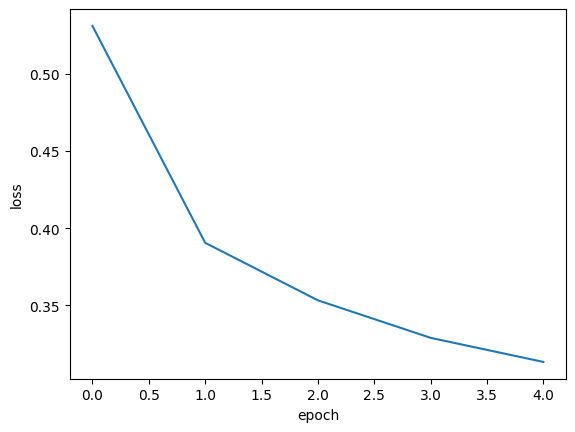

In [12]:
# 오답을 얼마나 줄여나갔는지를 보여주는 손실 곡선(Loss Curve) 그래프
# 우하향 그래프 학습 잘되고있는것
# 경사도 급격하다가 완만해짐, 큰특징을 먼저배우고 세부적인거 학습
import matplotlib.pyplot as plt

#1. history 딕셔너리에서 'loss' 리스트를 가져와 선 그래프 생성
# 에포크별 손실 값 순서대로 들어있음
plt.plot(history.history['loss'])

# 2. X축 : 훈련에포크횟수의미, 인덱스 0부터 ~ 4까지 5번
plt.xlabel('epoch')

# 3. y축 : 오차(손실)의 크기 의미
plt.ylabel('loss')

# 4. 그래프 출력
plt.show()

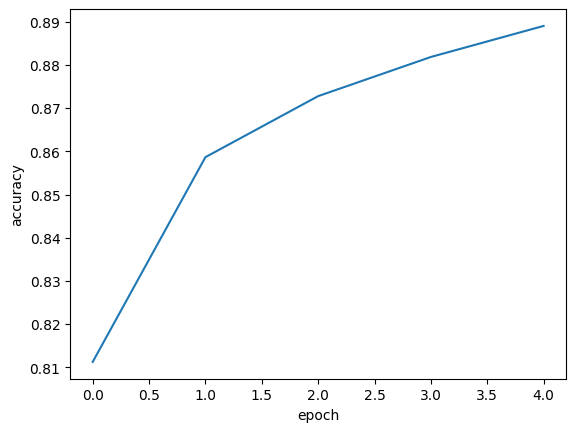

In [13]:
# accuracy 정확도 그래프 출력

plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [14]:
model=model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled,train_target, epochs=20, verbose=0)

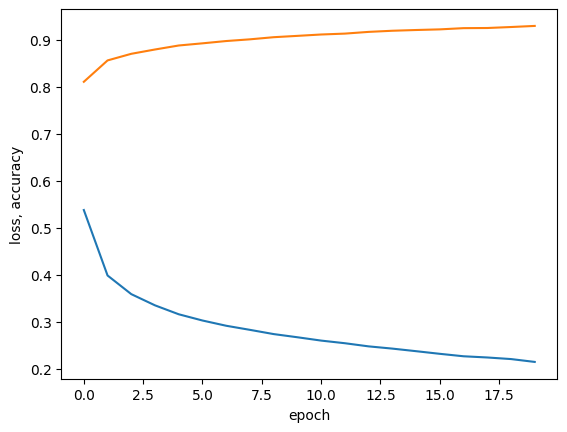

In [15]:
plt.plot(history.history['loss'])   # 손실율
plt.plot(history.history['accuracy']) # 정확도
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.show()

In [16]:
# 에포크 20번 학습 : 한계치 도달 과정 관찰
# 손실값이 어디까지 떨어지는지 확인
# 과적합(Overfitting) 유도 :훈련점수 좋아지나 테스트점는 제자리인 구간 발견

# 조기 종료 콜백 (Early Stopping)
# 최적의 타이밍 포착: 컴퓨터가 알아서 "더 이상 나아지지 않네? 여기서 멈출게!"라고 판단하게 만드는 것
# 자원 낭비 방지: 이미 최적의 성능이 나왔다면, 나머지 에포크는 시간과 전기세만 낭비

In [17]:
# 인공신경망은 손실 함수를 최소화하는 경사 하강법으로 학습되므로,
# 모델의 학습 상태를 정확히 진단하려면 훈련 세트와 검증 세트의 손실(Loss) 변화를 동시에 관찰
# '정확도'보다 미세한 오차를 반영하는 '손실(Loss)값이 최적화의 더 정밀한 지표입니다.
# 특히 훈련 손실은 낮아지는데 검증 손실이 다시 상승하는 지점이 바로 과대적합(Overfitting)의 시작점이므로,
# 두 손실 곡선을 비교 분석하여 최적의 학습 중단 시점을 결정해야 합니다.
#  keypoint https://wikidocs.net/236194

In [18]:
# 모델 생성 후 설정 넣고 실제 훈련시작

model = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 모델 생성 후 설정 넣고 실제 훈련시작
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))
                    # 검증 데이터 세트
                    # 훈련 데이터(train)로 공부하고, 매 에포크가 끝날 때마다
                    # 검증 데이터(val)로 시험을 쳐서 점수를 기록합니다

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7602 - loss: 0.6824 - val_accuracy: 0.8468 - val_loss: 0.4326
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8506 - loss: 0.4079 - val_accuracy: 0.8543 - val_loss: 0.4006
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8665 - loss: 0.3627 - val_accuracy: 0.8597 - val_loss: 0.3813
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8762 - loss: 0.3387 - val_accuracy: 0.8588 - val_loss: 0.3838
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8846 - loss: 0.3208 - val_accuracy: 0.8662 - val_loss: 0.3758
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8902 - loss: 0.3070 - val_accuracy: 0.8630 - val_loss: 0.3919
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8952 - loss: 0.2937 - val_accuracy: 0.8667 - val_loss: 0.3878
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9000 - loss: 0.2849 - 

In [19]:
# 내가 이모델로 뭘 확인할 수 있는지 볼 수 있음

print(history.history.keys())
# accuracy, loss 값
# 추가로 검증세트 val_accuracy, val_loss가 나옴

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


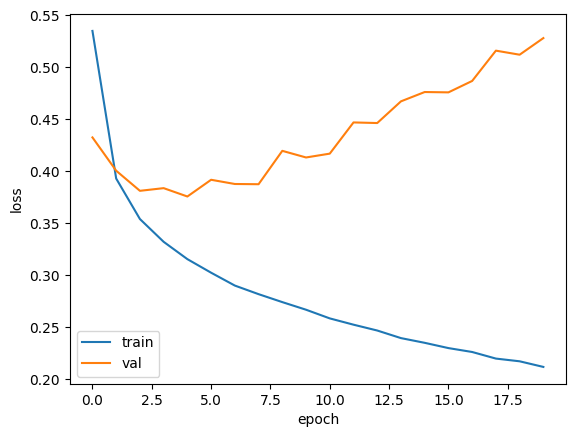

In [20]:
# 학습 결과를 확인 하기 위한 그래프

plt.plot(history.history['loss']) # 훈련손실변화
plt.plot(history.history['val_loss']) # 검증손실변화
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val']) #범례
plt.show()
# 결과 : 초기 감소하다가 다시 상승 , but 훈련손실은 계속 감소
#        학습은 잘됬지만 새로운 데이터에 대해 손실률 증가 -> 과대 적합
# 과대적합을 막는 신경망 전용 규제방법 -> 드롭아웃에 대해 고민


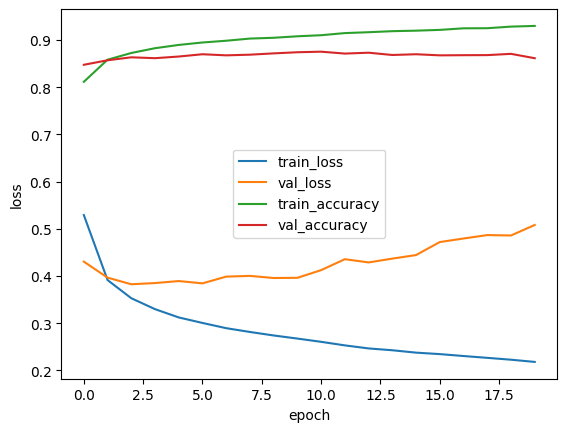

In [21]:
# 먼저 옵티마이저(최적화) 하이퍼파마리터를 자동 조절 하여 과대적합을 완화

model = model_fn() # 만들어둔 모델구조 호출 생성

model.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy',metrics=['accuracy']) # 모델 학습 설정
#              최적화RMSprop         손실함수 다중분류                    평가지표 정확성

history = model.fit(train_scaled, train_target, epochs=10, verbose=0, validation_data=(val_scaled,val_target)) # 훈련
#                                               10번       과정안보여주고   검증데이터까지

#그래프
plt.plot(history.history['loss'])         # 훈련 데이터의 손실값 (내려가는 것이 이상적)
plt.plot(history.history['val_loss'])     # 검증 데이터의 손실값 (다시 올라가면 과대적합)
plt.plot(history.history['accuracy'])     # 훈련 데이터의 정확도 (올라가는 것이 이상적)
plt.plot(history.history['val_accuracy']) # 검증 데이터의 정확도 (훈련 데이터와 격차 확인)

plt.xlabel('epoch') # 학습 횟수
plt.ylabel('loss')  # 값 (정확도와 손실이 혼재됨)
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()


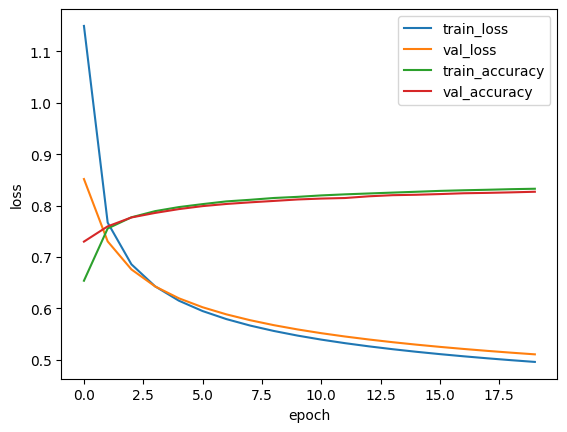

In [22]:
#. Adagrad
# 개별 가중치 맞춤: 모델의 수많은 파라미터(가중치) 중, 잘 아는 것은 학습률을 낮추고, 새로운 것은 학습률을 높게
# 학습의 안정성: 학습이 진행될수록 전체적인 학습률이 점차 줄어들기 때문에, 나중에는 세밀하게 최적점을 찾아가는 특징

model = model_fn() #모델구조생성
adagrad = keras.optimizers.Adagrad() #adagrad 옵티마이저 객체 생성
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy']) #모델학습설정

history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))
# 코랩과 파이참 vervose= 1 이 디폴트

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

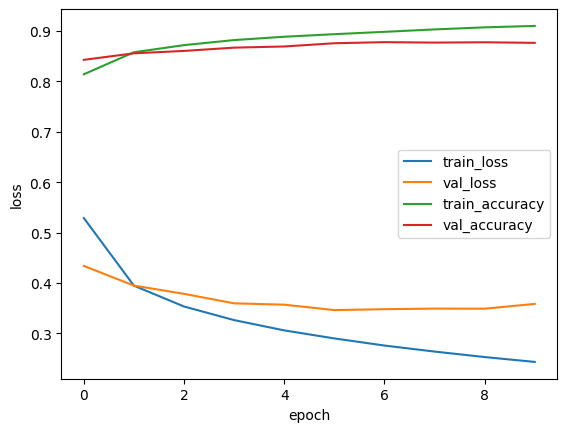

In [52]:
#Adam(Adaptive Moment Estimation) : 가려는 관성으로 쉽게 방향이 변하지않고 속도 조절에(기울기)에도 유리
model = model_fn()

# Adam은 기본적으로 학습률(learning rate)을 스스로 잘 조절
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습 (20 에포크 진행, 검증 데이터 포함)
history = model.fit(train_scaled, train_target, epochs=10, verbose=0, validation_data=(val_scaled, val_target))

# 훈련결과 그래프
plt.plot(history.history['loss'])         # 훈련 손실
plt.plot(history.history['val_loss'])     # 검증 손실 (이게 상승하면 과대적합 시작!)
plt.plot(history.history['accuracy'])     # 훈련 정확도
plt.plot(history.history['val_accuracy']) # 검증 정확도

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

In [24]:
# RMSprop : 속도중시, 기울기변화 큰쪽 학습률 낮추기, keras의 디폴트 옵티마이저, 손실값 요동침
# Adagrad : 보폭조정, 많이변한파라미터는 작게, 적게변한건 크게, 보폭이갈수록작아져 조기에 멈춤, 부드럽게하강 끝에는 변화거의없음
# Adam : 관성+보폭조정, 안정적이고빠름 , 매끄럽고 빠르게 최적점에 도달, 과대적합의 지점찾기 용이

In [25]:
# 여기까지는 안정적인 그래프로 들어왔으나, 과대적합을 막기위해 드롭아웃이 필요해보임

# 드롭아웃(Dropout): 과대적합을 막는 가장 강력,필수적도구
# 훈련 중 은닉층의 뉴런은 랜덤하게 끄기(0으로)
# 할때마다 다른 뉴런이 꺼지며, 훈련데이터는 새로운 신경망을 만남
# 드롭아웃 비율(p): 0~1 사이의 값으로 설정 (예: 0.3이면 뉴런의 30%를 제거)
# 특정 뉴런에 대한 의존성 감소, 더 견고하고 일반화된 특징(Feature) 학습
# 인접한뉴런의 도움없이 스스로 유의미한 특징 찾아내도록, 특정뉴런에 가중치올라가는거 방지
# 새로운 신경망 학습 -> 앙상블효과
# 주의력 분산 -> 특정입력값에 집중하지않고 입력된데이터의 전체적인 흐름 패턴 주의집

# 케라스에서 드롭아웃을 keras.layers.Dropout로 제공함

# 주의사항 : 훈련이 끝난 뒤 평가나 예측을 수행할 때는 드롭아웃을 적용하지 않는다.
# 훈련된 모든 뉴런을 사용해야 올바른 예측이 수행됨
# 텐서플로와 케라스는 모델을 평가와 예측에 사용할 때 자동으로 드롭아웃을 적용하지 않음

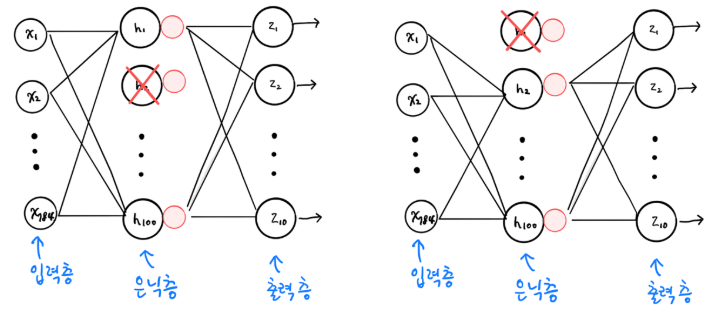

In [53]:
# model_fn 함수에 드롭 아웃 객체를 전달하여 층을 추가함
model = model_fn(keras.layers.Dropout(0.3)) # 30% 정도 드롭 아웃
model.summary()
#세번째 추가된 레이어 드롭아웃은 데이터의 형식 변하지않음, 훈련파라미터없음, INPUT=OUTPUT

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_18 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 - 5s - 3ms/step - accuracy: 0.7946 - loss: 0.5894 - val_accuracy: 0.8431 - val_loss: 0.4300
Epoch 2/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8422 - loss: 0.4391 - val_accuracy: 0.8599 - val_loss: 0.3809
Epoch 3/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8542 - loss: 0.3987 - val_accuracy: 0.8615 - val_loss: 0.3725
Epoch 4/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8622 - loss: 0.3793 - val_accuracy: 0.8718 - val_loss: 0.3525
Epoch 5/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8661 - loss: 0.3675 - val_accuracy: 0.8745 - val_loss: 0.3423
Epoch 6/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8729 - loss: 0.3478 - val_accuracy: 0.8760 - val_loss: 0.3365
Epoch 7/10
1500/1500 - 6s - 4ms/step - accuracy: 0.8757 - loss: 0.3407 - val_accuracy: 0.8808 - val_loss: 0.3297
Epoch 8/10
1500/1500 - 9s - 6ms/step - accuracy: 0.8794 - loss: 0.3295 - val_accuracy: 0.8763 - val_loss: 0.3390
Epoch 9/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8807 - loss: 0.3228 - val_accuracy: 0.8783 - 

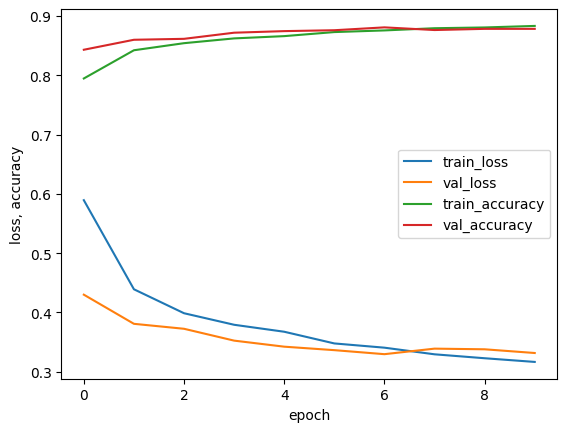

In [54]:
# 훈련 손실과 검증 손실의 그래프를 그려보자.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=10, verbose=2, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

# 과대 적합이 초반 줄어 듬 10번째 에포크가 검증 손실의 감소가 멈추지만 크게 상승하지 않음
# 과대적합이 에포크가 늘수록 증가함, 적정 횟수 찾아야함

In [57]:
# 학습된 결과물을 저장하기

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=10, verbose=0, validation_data=(val_scaled, val_target)) # 학습

# 전체모델 저장 (구조, 가중치, 최적화상태), 복원 : model = keras.models.load_model('...')
# 크기큼, 다른환경에서모델 실행할때, 코드 없이도 바로 복원 가능 -> 배포 / 추론용으로 많이 사용
model.save('model-whole-ep10.keras')

# 가중치만 저장((Weights)
# 학습된 파라미터들만 저장, HDF5포맷 저장, 작음, 구조는있고 학습결과만 바꿀,
# 모델 구조 코드를 다시 만들어야 함 -> 실험 중간 체크포인트로 많이 사용
#model.save_weights('model-ep10.weights.h5')

In [60]:
# 가중치만 불러오기 (똑같은 모델 구조가 미리 선언되어 있어야 함)
#model2 = model_fn(keras.layers.Dropout(0.3)) # 구조 생성
#model2.load_weights('model-ep10.weights.h5') # 숫자(가중치) 채우기

# 모델 전체 불러오기 (구조 선언 필요 없음)
from tensorflow import keras
model3 = keras.models.load_model('model-whole-ep10.keras')

In [30]:

# model.keras (케라스모델 구조 : with zipfile.ZipFile("model.keras", 'r') as z:
#                                print(z.namelist()) )
#                                ['config.json', 'metadata.json', 'model.weights.h5']
#  ├ config.json
#  ├ metadata.json
#  └ model.weights.h5

# config.json (모델 구조)
# {
#  "class_name": "Sequential",
#  "config": {
#    "layers": [
#      {
#        "class_name": "Dense",
#        "config": {
#          "units": 64,
#          "activation": "relu"
#        }
#      }
#    ]
#  }
# }


# model.weights.h5 (가중치)
# dense/kernel:0
# dense/bias:0
# dense_1/kernel:0
# dense_1/bias:0
# -> 실제 값 : 가중치만 저장(엔진만 저장)
#  0.2312
# -0.7811
#  0.5321

# metadata.json
# {
#  "keras_version": "3.0",
#  "backend": "tensorflow"
# }

# .keras 파일은 사실 ZIP 압축 포맷입니다.
# 내부를 열어보면 모델 설계도(JSON)와 실제 값(H5)이 분리되어 저장되어 있습니다.

# [config.json 예시 해석]
# "class_name": "Sequential" -> 순차적으로 층을 쌓는 모델 방식임
# "units": 64, "activation": "relu" -> 64개의 뉴런과 ReLU 함수를 사용한 층 정보를 기록

# [model.weights.h5 예시 해석]
# kernel: 가중치 (입력값이 출력에 미치는 영향력)
# bias: 절편 (뉴런의 활성화 민감도를 조절하는 상수)
# 이 파일만 있으면 똑같은 구조의 모델에 '지능'을 그대로 주입할 수 있습니다.


In [61]:
# 저장된 모델 실행
!ls -al model*

-rw-r--r-- 1 root root 976600 Mar  6 06:11 model-ep10.weights.h5
-rw-r--r-- 1 root root 979413 Mar  6 06:15 model-whole-ep10.keras


In [62]:
# 드롭아웃포함 모델구조 생성 (장할 당시의 모델 구조(model_fn)와 동일해야 가중치가 정확히 매칭)
model = model_fn(keras.layers.Dropout(0.3)) # 훈련하지 않은 새로운 모델

#저장되어 있던 숫자들(가중치와 절편)을 모델의 각 층에 주입
model.load_weights('model-ep10.weights.h5')

# 구조,데이터형식,파라미터개수
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# 모델 검증 정확도 확인!
import numpy as np

# 1. 모델을 사용해 검증 세트의 예측 확률값을 계산
# 결과값 크기: (12000, 10) -> 12,000개의 샘플 각각에 대해 10개 클래스의 확률 존재
predictions = model.predict(val_scaled)

# 2. 각 샘플마다 가장 높은 확률을 가진 클래스의 인덱스를 선택
# axis=-1은 마지막 차원(여기서는 각 행의 10개 열)을 기준으로 최대값을 찾으라는 의미
val_labels = np.argmax(predictions, axis=-1)

# 3. 예측한 인덱스(val_labels)와 실제 정답(val_target)을 비교
# 결과: [True, False, True, ...] 형태의 불리언 배열 생성 (같으면 True/1, 다르면 False/0)
correct_predictions = (val_labels == val_target)

# 4. 비교 결과의 평균을 내어 정확도(Accuracy) 산출
# True는 1로, False는 0으로 계산되어 전체 평균이 곧 정확도가 됨
accuracy = np.mean(correct_predictions)

print(f"검증 정확도: {accuracy * 100:.2f}%") # 결과 예: 87.96%

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step
검증 정확도: 88.06%


In [63]:
from tensorflow import keras

# 1. 모델 설계도 + 가중치 + 컴파일 설정까지 한 번에 복원
#  저장했던 '완성품' 파일 전체 불러오기
model = keras.models.load_model('model-whole-ep10.keras')

# 2. 불러온 모델의 성능 측정
# np.argmax로 직접 계산했던 것과 동일한 검증 정확도가 출력
# evaluate()는 내부적으로 loss와 accuracy를 반환
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8854 - loss: 0.3231


[0.3303162455558777, 0.8808333277702332]

In [35]:
#2. 한 번에 끝내는 : 케라스 콜백 (Callbacks)
#주석에서 언급하신 콜백(Callback)은 훈련 과정 중에 일어나는 일들을 모니터링하고 자동으로 조치
#① ModelCheckpoint (가장 좋은 순간 기록)
#훈련을 20번 하더라도, 그중 검증 점수가 가장 좋았던 순간의 가중치를 자동으로 파일에 저장해 줍니다.
#훈련이 끝난 후 우리는 그냥 그 파일만 불러오면 됩니다.

#② EarlyStopping (적절할 때 멈추기)
# val_loss가 더 이상 떨어지지 않고 상승하기 시작하면, 설정한 에포크가 다 끝나지 않았더라도 학습을 강제로 종료합니다.
# "검증 점수가 상승하는 지점"을 컴퓨터가 알아서 찾는 방식입니다.

In [65]:
# 두번 훈련하지않고 가장 최적의 모델 찾기

# 1. 체크포인트: 최적의 모델을 'best-model.keras'라는 이름으로 자동 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)

# 2. 조기 종료: 검증 손실(val_loss)이 2번 연속 개선되지 않으면 멈춤
# restore_best_weights=True를 설정하면 멈춘 시점이 아니라 '가장 좋았던 때'의 가중치로 복구합니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

# 3. 학습 시 callbacks 매개변수에 리스트로 전달
history = model.fit(train_scaled, train_target, epochs=10, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8861 - loss: 0.3034 - val_accuracy: 0.8807 - val_loss: 0.3241
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8898 - loss: 0.2992 - val_accuracy: 0.8825 - val_loss: 0.3245
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8912 - loss: 0.2938 - val_accuracy: 0.8840 - val_loss: 0.3198
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8910 - loss: 0.2888 - val_accuracy: 0.8846 - val_loss: 0.3252
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8931 - loss: 0.2840 - val_accuracy: 0.8852 - val_loss: 0.3228


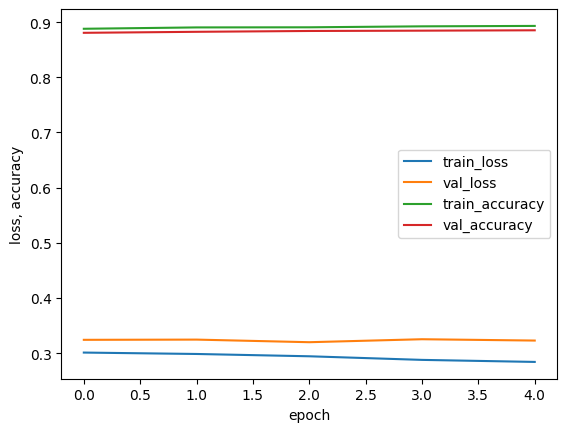

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8857 - loss: 0.3144


[0.3198102116584778, 0.8840000033378601]

In [66]:
# 확인
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)
# 결론 20번을 다 돌리고 좋은 점수가 나온 4번째 에포크를 저장함.

In [67]:
# 1. 모델 구조 생성 (드롭아웃 30% 적용)
model = model_fn(keras.layers.Dropout(0.3))

# 2. 모델 설정 (Adam 옵티마이저 사용)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# 3. 모델 체크포인트 설정: 검증 손실(val_loss)이 '최저'일 때만 'best-model.keras'로 자동 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)

# 4. 조기 종료 설정:
# - patience=2: 검증 손실이 2번 연속으로 줄어들지 않으면 학습 중단
# - restore_best_weights=True: 중단된 시점이 아니라, '가장 좋았던 순간'의 가중치로 모델을 원복
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

# 5. 학습 실행: callbacks 리스트에 두 비서를 넣어 감시하도록 함
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])
# 6. 조기종료시점에포크
print(early_stopping_cb.stopped_epoch)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7321 - loss: 0.7712 - val_accuracy: 0.8463 - val_loss: 0.4232
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8357 - loss: 0.4524 - val_accuracy: 0.8603 - val_loss: 0.3821
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8528 - loss: 0.4088 - val_accuracy: 0.8680 - val_loss: 0.3563
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8581 - loss: 0.3859 - val_accuracy: 0.8751 - val_loss: 0.3434
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8661 - loss: 0.3672 - val_accuracy: 0.8744 - val_loss: 0.3398
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8707 - loss: 0.3542 - val_accuracy: 0.8784 - val_loss: 0.3358
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8746 - loss: 0.3425 - val_accuracy: 0.8798 - val_loss: 0.3296
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8781 - loss: 0.3311 - 

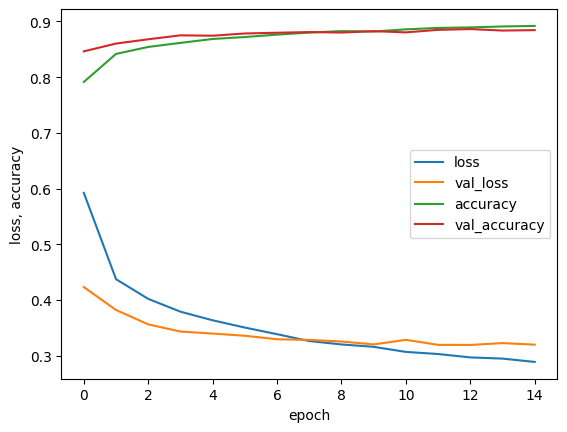

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8851 - loss: 0.3169


[0.3192969858646393, 0.8863333463668823]

In [68]:
#확인

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['loss', 'val_loss','accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)